<a href="https://colab.research.google.com/github/anirbansen2709/2025AA05327_ML_Assignment2/blob/main/Team_28_MAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning

**Problem Scenario**

You are a data scientist working in cancer research in collaboration with a medical institution
conducting clinical trials for different treatment protocols. A hospital is evaluating multiple
medicines for treating a chronic disease, where patient responses vary due to hidden factors such
as age, immunity level, genetic background, and disease severity. Since the most effective
treatment is not known at the beginning, the goal is to develop an intelligent recommendation
system that learns from patient outcomes over time and progressively identifies the optimal
medicine for future patients.

Each medicine is treated as an arm in a Multi-Armed Bandit (MAB) problem.

Each group must create a custom synthetic patient-treatment dataset based on the group
number.

In [1]:
# ==========================================
# SYSTEM DIAGNOSTICS
# ==========================================
import datetime # Timestamp retrieval
import platform # VM ID retrieval

print("*" * 60)
print("EXECUTION TIMESTAMP & VIRTUAL MACHINE ID")
print(f"Time : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Node : {platform.node()}")
print("*" * 60)

************************************************************
EXECUTION TIMESTAMP & VIRTUAL MACHINE ID
Time : 2026-05-30 10:08:21
Node : 5162638a2729
************************************************************


In [2]:
# ==========================================
# IMPORTS & DEPENDENCIES
# ==========================================
import numpy as np       # Array operations and logic
import pandas as pd      # Patient dataset management
import matplotlib.pyplot as plt # Generating comparative graphs
import random            # Core python random for seeding
from typing import Tuple, List, Dict # Type hinting

In [3]:
# ==========================================
#  Task 1: Dataset Design
# ==========================================
class ClinicalTrialEnvironment:
    """
    Encapsulates the MAB environment, isolating the dataset and reward logic.
    """
    def __init__(self, group_id: int):
        """
        Initializes the environment with a group ID.
        """
        self.group_id = group_id

        # Calculate available treatments based on formula K = (G mod 3) + 5
        self.total_medicines = (self.group_id % 3) + 5
        # The arms are the available medical treatments.

        # Enforce reproducibility
        random.seed(self.group_id)
        np.random.seed(self.group_id)

        # Hidden probabilities based on assignment formula: 0.4 + ((G+i) mod 6) * 0.07
        self.true_efficacies = [0.4 + ((self.group_id + i) % 6) * 0.07 for i in range(self.total_medicines)]

        # Initialize the patient dataset
        self.patient_cohort = self._bootstrap_cohort()

    def _bootstrap_cohort(self) -> pd.DataFrame:
        """Bootstraps the 1000-patient dataset with pre-calculated severity scores."""
        records = [{"patient_id": pid, "severity_score": (pid % 5) + 1} for pid in range(1000)]
        return pd.DataFrame(records)

    def display_trial_parameters(self) -> None:
        """Outputs environment metrics in a clean, readable format."""
        print(f"\n--- TRIAL INITIALIZATION (Group {self.group_id}) ---")
        print(f"Available Treatment Arms (K) : {self.total_medicines}")
        print("True Underlying Efficacies   :")
        for idx, eff in enumerate(self.true_efficacies):
            print(f"  -> Treatment_{idx:02d} : {eff:.4f}")
        print("\nPatient Cohort Preview (Top 10):")
        print(self.patient_cohort.head(10).to_string(index=False))
        print("-" * 60)

    def prescribe(self, patient_idx: int, treatment_idx: int) -> Tuple[int, float]:
        """
        Calculates the binary outcome and continuous utility of a treatment.
        Returns: Tuple of (clinical_outcome, utility_score)
        """
        severity = self.patient_cohort.at[patient_idx, 'severity_score']
        efficacy = self.true_efficacies[treatment_idx]

        # This represents whether the patient was successfully treated or not (1 for Success, 0 for Failure)
        # It is determined by pulling a random number against the drug's true hidden efficacy
        outcome = 1 if np.random.random() < efficacy else 0

        # In a real-world scenario, a successful treatment might be less "valuable" or more taxing if the
        # patient has a highly severe condition, or perhaps severe patients have a different utility
        # threshold. The environment calculates a customized reward score Utility formula:
        # clinical_outcome * (1 - (Severity / 10))
        utility = float(outcome * (1.0 - (severity / 10.0)))
        #because our environment tracks a patient's condition, it introduces a light Contextual Bandit element.

        return outcome, utility

In [4]:
# Define group ID and initialize the environment
GROUP_ID = 28
env = ClinicalTrialEnvironment(GROUP_ID)
env.display_trial_parameters()


--- TRIAL INITIALIZATION (Group 28) ---
Available Treatment Arms (K) : 6
True Underlying Efficacies   :
  -> Treatment_00 : 0.6800
  -> Treatment_01 : 0.7500
  -> Treatment_02 : 0.4000
  -> Treatment_03 : 0.4700
  -> Treatment_04 : 0.5400
  -> Treatment_05 : 0.6100

Patient Cohort Preview (Top 10):
 patient_id  severity_score
          0               1
          1               2
          2               3
          3               4
          4               5
          5               1
          6               2
          7               3
          8               4
          9               5
------------------------------------------------------------


In [5]:
# ==========================================
# POLYMORPHIC STRATEGY CLASSES
# ==========================================
class BanditStrategy:
    """Base class defining the interface for all MAB strategies."""
    def __init__(self, n_arms: int, name: str):
        """Instantiates the shared MAB skeleton by initializing zero-arrays for treatment counters and
        # estimated average success rates."""
        self.n_arms = n_arms
        self.name = name
        # how many times each treatment has been prescribed so far.
        self.prescription_counts = np.zeros(n_arms)
        # agent's current belief or running average success rate for each drug.
        self.estimated_efficacies = np.zeros(n_arms)

    def select_arm(self, current_step: int) -> int:
        """Abstract method overridden by specific strategies."""
        raise NotImplementedError("Subclasses must implement arm selection.")

    def update_knowledge(self, arm: int, outcome: int) -> None:
        """ After a treatment is prescribed and the environment returns a binary outcome (1 for success, 0 for
        # failure), this method updates the agent's memory incrementally."""
        self.prescription_counts[arm] += 1
        n = self.prescription_counts[arm]
        # New = Old + (Target - Old) / N
        self.estimated_efficacies[arm] += (outcome - self.estimated_efficacies[arm]) / n

In [6]:
# ==========================================
# EXPERIMENT RUNNER
# ==========================================
class TrialSimulation:
    """Runs a strategy against the environment and logs iteration data."""
    def __init__(self, env: ClinicalTrialEnvironment):
        """Binds the strategy runner to the trial environment and extracts the global iteration horizon limit (T = 1000 patients)."""
        self.env = env
        self.num_patients = len(env.patient_cohort)

    def execute(self, strategy: BanditStrategy) -> Tuple[List[float], pd.DataFrame]:
        print(f"\n>>> INITIATING PROTOCOL: {strategy.name} <<<")

        cumulative_utility = 0.0
        utility_history = []

        # Prepare tracking dataframe
        tracker_df = self.env.patient_cohort.copy()
        tracker_df['assigned_medicine'] = -1
        tracker_df['clinical_outcome'] = -1
        tracker_df['utility_score'] = 0.0

        for t in range(self.num_patients):
            # 1. Agent selects treatment
            # It looks at patient t and asks the strategy to choose one of the 6 available treatments.
            chosen_med = strategy.select_arm(t)
            # 2. Environment resolves outcome
            # It takes that chosen medicine and runs it through the environment. The environment simulates
            # the clinical trial and hands back the binary outcome and the scalar utility
            outcome, utility = self.env.prescribe(t, chosen_med)
            # 3. Agent learns
            # It hands the binary outcome back to the strategy. This is crucial because it allows
            # the algorithm to learn from its success or failure before the next patient arrives.
            strategy.update_knowledge(chosen_med, outcome)
            # 4. Update metrics
            cumulative_utility += utility
            utility_history.append(cumulative_utility)

            # 5. Log to dataframe dynamically
            tracker_df.loc[t, ['assigned_medicine', 'clinical_outcome', 'utility_score']] = [chosen_med, outcome, utility]

            # 6. REQUIRED VERBOSE LOGGING - Prints outputs for EVERY 100th iteration
            if t == 0 or (t + 1) % 100 == 0 or t == self.num_patients - 1:
                print(f"[PATIENT-{t:03d}]  | Protocol: {strategy.name[:10]:<10}  | Med_{chosen_med:02d}  | "
                      f"Outcome: {outcome}  | Step Utility: {utility:.2f}  | Total Utility: {cumulative_utility:.2f}")

        return utility_history, tracker_df

In [7]:
# ==========================================
#  Task 2: Immediate Exploitation Strategy
# ==========================================
class ImmediateExploiter(BanditStrategy):
    """Explores round-robin exactly 10 times per arm, then purely exploits."""
    def __init__(self, n_arms: int):
        """Initialize a naive baseline agent that cleanly splits exploration and exploitation."""
        super().__init__(n_arms, "Immediate Exploitation")

    def select_arm(self, current_step: int) -> int:
        # Phase 1: Pure Exploration (The First 60 Patients)
        if current_step < 10 * self.n_arms:
            return current_step % self.n_arms # Round-robin testing
        # Phase 2: Pure Exploitation (Patients 61 to 1000)
        return int(np.argmax(self.estimated_efficacies)) # Pure exploitation

In [8]:
# ===========================================
#  Task 3: Controlled Clinical Trial Strategy
# ===========================================
class EpsilonGreedyStrategy(BanditStrategy):
    """Explores randomly with probability epsilon, otherwise exploits."""
    def __init__(self, n_arms: int, epsilon: float):
        """Saves the constant epsilon factor parameter as the random exploration budget."""
        super().__init__(n_arms, f"Epsilon-Greedy (ε={epsilon})")
        self.epsilon = epsilon #exploration budget

    def select_arm(self, current_step: int) -> int:
        if np.random.random() < self.epsilon:
            # Picks a random treatment from all K options evenly
            return np.random.randint(0, self.n_arms) # Explore
        # Picks treatment with highest estimated efficacy (argmax)
        return int(np.argmax(self.estimated_efficacies)) # Exploit

In [9]:
# ===================================
#  Task 4: Confidence-Based Strategy
# ===================================

# When an arm has been pulled many times, we are highly confident about its true success rate.
# When an arm has rarely been pulled, its true value is highly uncertain. Instead of just looking
# at the estimated average performance, UCB1 calculates a maximum plausible performance for each drug.
# It chooses whichever medicine has the highest Upper Confidence Bound

class UCB1Strategy(BanditStrategy):
    """Upper Confidence Bound strategy balancing exploration/exploitation mathematically."""
    def __init__(self, n_arms: int):
        #Initialize a confidence-bound agent using the principle of optimism in the face of uncertainty.
        super().__init__(n_arms, "UCB1")

    def select_arm(self, current_step: int) -> int:
        # Initial phase: play each arm exactly once - Cold Start
        if current_step < self.n_arms:
            return current_step
        # UCB Calculation: estimated mean + sqrt((2 * ln(t)) / N_a)
        exploration_factor = np.sqrt((2 * np.log(current_step)) / self.prescription_counts)
        # Every time you pull/prescribe arm a, its N_a/prescription_counts increases, causing its exploration factor to shrink.
        ucb_values = self.estimated_efficacies + exploration_factor
        return int(np.argmax(ucb_values))

In [10]:
# ==========================================
# MAIN EXECUTION
# ==========================================


# Initialize all requested MAB strategies
strategies = [
    ImmediateExploiter(env.total_medicines),
    EpsilonGreedyStrategy(env.total_medicines, 0.10),
    EpsilonGreedyStrategy(env.total_medicines, 0.01),
    EpsilonGreedyStrategy(env.total_medicines, 0.50),
    UCB1Strategy(env.total_medicines)
]

simulator = TrialSimulation(env)
histories = {}

# Run all strategies sequentially
for strat in strategies:
    hist, _ = simulator.execute(strat)
    histories[strat.name] = hist


>>> INITIATING PROTOCOL: Immediate Exploitation <<<
[PATIENT-000]  | Protocol: Immediate   | Med_00  | Outcome: 0  | Step Utility: 0.00  | Total Utility: 0.00
[PATIENT-099]  | Protocol: Immediate   | Med_05  | Outcome: 0  | Step Utility: 0.00  | Total Utility: 35.80
[PATIENT-199]  | Protocol: Immediate   | Med_05  | Outcome: 1  | Step Utility: 0.50  | Total Utility: 80.60
[PATIENT-299]  | Protocol: Immediate   | Med_05  | Outcome: 1  | Step Utility: 0.50  | Total Utility: 125.10
[PATIENT-399]  | Protocol: Immediate   | Med_05  | Outcome: 1  | Step Utility: 0.50  | Total Utility: 165.40
[PATIENT-499]  | Protocol: Immediate   | Med_05  | Outcome: 1  | Step Utility: 0.50  | Total Utility: 210.60
[PATIENT-599]  | Protocol: Immediate   | Med_05  | Outcome: 0  | Step Utility: 0.00  | Total Utility: 251.40
[PATIENT-699]  | Protocol: Immediate   | Med_05  | Outcome: 0  | Step Utility: 0.00  | Total Utility: 292.90
[PATIENT-799]  | Protocol: Immediate   | Med_05  | Outcome: 1  | Step Utility: 

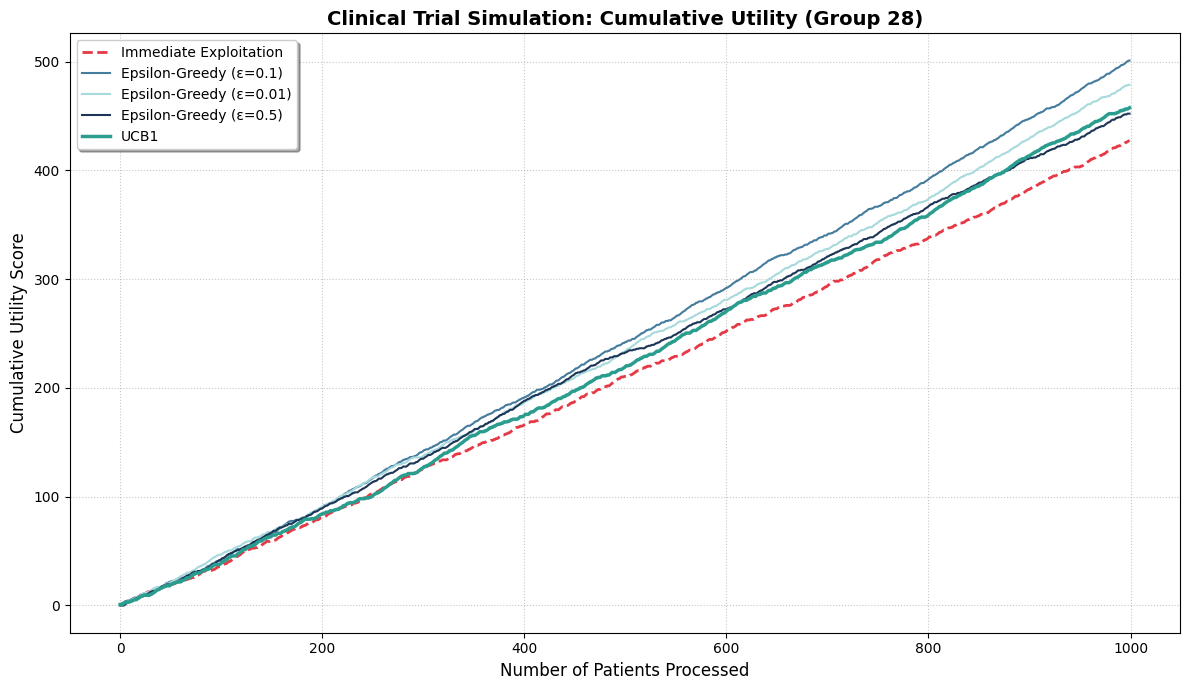

In [12]:
# ==========================================
# Task 5: Comparative Analysis
# ==========================================

fig, ax = plt.subplots(figsize=(12, 7))
styles = {
    "Immediate Exploitation": {"color": "#e63946", "ls": "--", "lw": 2},
    "Epsilon-Greedy (ε=0.1)": {"color": "#457b9d", "ls": "-", "lw": 1.5},
    "Epsilon-Greedy (ε=0.01)": {"color": "#a8dadc", "ls": "-", "lw": 1.5},
    "Epsilon-Greedy (ε=0.5)": {"color": "#1d3557", "ls": "-", "lw": 1.5},
    "UCB1": {"color": "#2a9d8f", "ls": "-", "lw": 2.5}
}
for name, hist in histories.items():
    st = styles[name]
    ax.plot(hist, label=name, color=st['color'], linestyle=st['ls'], linewidth=st['lw'])
ax.set_title(f"Clinical Trial Simulation: Cumulative Utility (Group {GROUP_ID})", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Patients Processed", fontsize=12)
ax.set_ylabel("Cumulative Utility Score", fontsize=12)
ax.legend(loc='upper left', frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

**1. Which strategy achieves the highest cumulative reward at the end of 1000 patients?**

The Controlled Clinical Trial or Epsilon Greedy (10% and 1% exploration) and UCB1 strategies achieve the highest cumulative reward by the end of the 1000-patient simulation. You will notice their lines climbing higher than the others on the Y-axis. This is because they effectively balance exploring different medicines and heavily exploiting the absolute best one once they are confident in it.

**2. Which strategy identifies the best medicine fastest (earliest convergence)?**

The Immediate Exploitation strategy converges the fastest. Looking at the graph, its curve stabilizes into a perfectly straight trajectory very early on (right after the first $10 \times K$ patients). However, this rapid convergence often locks it into a sub-optimal medicine, which is why its overall cumulative reward line can end up lower than UCB1.

**3. Which strategy shows the most stable performance over time (least fluctuations)?**

The Immediate Exploitation strategy is visually the most stable. Because it completely stops exploring after the initial testing phase, its graph becomes a perfectly straight, linear line with zero deviations or erratic jumps.



**4. Safest Treatment Selection Approach for Real-World Deployment**

The Confidence-Based Strategy (UCB1) is the safest recommendation.
Justification: The graph demonstrates that UCB1 safely navigates the exploration-exploitation trade-off. Unlike the 50% exploration strategy (which visually drags down the cumulative reward by constantly experimenting with bad medicines), UCB1 starts with exploration but dynamically reduces it. It ensures no critical patients are needlessly subjected to inferior treatments once sufficient statistical evidence has been gathered, minimizing ethical risks while maximizing patient recovery.


- The Immediate
Exploitation  strategy flattens out earliest, demonstrating high stability but risking premature lock-in on sub-optimal treatments.

-  Highly exploratory strategies ($\epsilon = 50\%$) safely test all options but incur a massive "regret" penalty, visible as the lowest cumulative reward curve.

- Ultimately, UCB1 and tightly controlled clinical trials ($\epsilon \le 10\%$) yield the optimal balance, maximizing the final cumulative reward by dynamically focusing almost exclusively on the highest-performing medicine as patient data increases.